# LLM-Based Material Transport Simulation

**マップ**: `/Game/Maps/Level`

**前提**: Unreal Engine でレベルを Play 状態にしてから実行してください。

**現在の既定マテリアル**: `box`

**補足**: SpotDog には Humanoid のような公開された PickUp API がないため、軽量物体を背上に保持して運ぶ演出で搬送を表現します。

## シナリオ概要

1. Humanoid（作業管理者）とロボット（SpotDog）を同じ場所にスポーン
2. 搬送対象のマテリアルを指定位置にスポーン
3. **Humanoid がテンプレートから自然言語指示を生成（LLM不使用）**
4. **ロボット搭載LLMがその自然言語を解釈し、構造化タスク指示に変換**
5. ロボットがタスク指示を実行:
   - Phase 1: マテリアル置き場へ移動
   - Phase 2: マテリアルをピックアップ演出で保持
   - Phase 3: ホームベースへ帰還・マテリアルを降ろす
6. 軌跡データを記録して可視化

## LLM 指示生成フロー

```
Humanoid（人間）
  └─ テンプレートから自然言語指示を生成（LLM不使用）
  └─ 例: "Robot, please go to (x, y) cm, pick up the box, and return to (hx, hy) cm."
        ↓
Robot 搭載LLM
  └─ システムプロンプト: 搬送ロボットの車載AIロール
  └─ ユーザープロンプト: 自然言語指示 + ロボット現在位置
  └─ 出力 (JSON): { material_location, return_location, task_description }
        ↓
RobotExecutor（ルールベース状態機械）
  └─ IDLE → NAVIGATING_TO_MATERIAL → PICKING_UP → CARRYING → NAVIGATING_HOME → DROPPING → DONE
```


# 初期設定

In [1]:
import math
import sys
import threading
import time
from enum import Enum
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydantic import BaseModel

# SimWorld ルートをパスに追加。
# Notebook 実行時はカレントディレクトリが変わるため、親ディレクトリを探索して特定する。
def _find_project_root() -> Path:
    search_starts = []
    if "__file__" in globals():
        search_starts.append(Path(__file__).resolve().parent)
    search_starts.append(Path.cwd().resolve())

    for start in search_starts:
        for candidate in (start, *start.parents):
            if (candidate / "setup.py").exists() and (candidate / "simworld").is_dir():
                return candidate

    if "__file__" in globals():
        return Path(__file__).resolve().parent.parent.parent
    return Path.cwd().resolve()


_root = _find_project_root()
sys.path.append(str(_root))
_output_dir = Path(__file__).resolve().parent if "__file__" in globals() else (_root / "dev" / "llm_material_transport")

from dotenv import load_dotenv

# プロジェクトルートの .env を読み込む (OPENROUTER_API_KEY などを環境変数に設定)
_env_path = _root / ".env"
if _env_path.exists():
    load_dotenv(_env_path)
    print(f"[.env] Loaded from {_env_path}")
else:
    print(f"[.env] Not found at {_env_path} — using system environment variables.")

from simworld.agent.humanoid import Humanoid
from simworld.communicator.communicator import Communicator
from simworld.communicator.unrealcv import UnrealCV
from simworld.llm.a2a_llm import A2ALLM
from simworld.utils.vector import Vector

ucv = None
communicator = None


def ensure_connection() -> Tuple[UnrealCV, Communicator]:
    """UnrealCV/Communicator を必要時に初期化して返す。"""
    global ucv, communicator

    if ucv is None:
        ucv = UnrealCV()
    else:
        ucv.check_connection()

    if communicator is None or communicator.unrealcv is not ucv:
        communicator = Communicator(ucv)

    return ucv, communicator


plt.style.use("seaborn-v0_8-whitegrid")

[.env] Loaded from C:\Users\thewi\Dropbox\03_ARCHES\01_main\01_HRC\03_simulation\SimWorld\.env


# パラメータ設定

In [2]:
# ---- エージェント/アセット設定 ----
HUMAN_BP_PATH = "/Game/TrafficSystem/Pedestrian/Base_User_Agent.Base_User_Agent_C"
ROBOT_BP_PATH = "/Game/Robot_Dog/Blueprint/BP_SpotRobot.BP_SpotRobot_C"
ROBOT_NAME    = "MT_SpotRobot"

# ---- マテリアル設定 ----
# "mug"  → /Game/InteractableAsset/Cup/BP_Mug.BP_Mug_C
# "box"  → /Game/InteractableAsset/Box/BP_Interactable_Box.BP_Interactable_Box_C
MATERIAL_PRESET = "box"
MATERIAL_PRESETS = {
    "mug": {
        "bp_path": "/Game/InteractableAsset/Cup/BP_Mug.BP_Mug_C",
        "name": "MT_MaterialMug",
        "label": "mug",
        "scale": (1.0, 1.0, 1.0),
        "carry_forward_cm": -5.0,
        "carry_side_cm": -20.0,
        "carry_z_cm": 92.0,
        "carry_proxy_bp_path": "/Game/CityDatabase/blueprints/BP_Box.BP_Box_C",
        "carry_proxy_name": "MT_MaterialMugCarryProxy",
        "carry_proxy_scale": (0.22, 0.22, 0.22),
        "drop_z_cm": 6.0,
    },
    "box": {
        "bp_path": "/Game/InteractableAsset/Box/BP_Interactable_Box.BP_Interactable_Box_C",
        "name": "MT_MaterialBox",
        "label": "box",
        "scale": (0.5, 0.5, 0.5),
        "carry_forward_cm": 50.0,
        "carry_side_cm": 0.0,
        "carry_z_cm": 60.0,
        # 箱自身の BP をプロキシとして使う。
        # スポーン直後に物理 OFF → 以降 set_location が確実に反映される。
        # 既に物理が起動した実アクターは hide して退避させる。
        "carry_proxy_bp_path": "/Game/InteractableAsset/Box/BP_Interactable_Box.BP_Interactable_Box_C",
        "carry_proxy_name": "MT_MaterialBoxCarryProxy",
        "carry_proxy_scale": (0.5, 0.5, 0.5),
        "drop_z_cm": 20.0,
    },
}

if MATERIAL_PRESET not in MATERIAL_PRESETS:
    raise ValueError(f"Unsupported MATERIAL_PRESET: {MATERIAL_PRESET}")

_material_config = MATERIAL_PRESETS[MATERIAL_PRESET]
MATERIAL_BP_PATH = _material_config["bp_path"]
MATERIAL_NAME = _material_config["name"]
MATERIAL_LABEL = _material_config["label"]
MATERIAL_SCALE = _material_config["scale"]
MATERIAL_CARRY_FORWARD_CM = _material_config["carry_forward_cm"]
MATERIAL_CARRY_SIDE_CM = _material_config["carry_side_cm"]
MATERIAL_CARRY_Z_CM = _material_config["carry_z_cm"]
MATERIAL_CARRY_PROXY_BP_PATH = _material_config.get("carry_proxy_bp_path")
MATERIAL_CARRY_PROXY_NAME = _material_config.get("carry_proxy_name")
MATERIAL_CARRY_PROXY_SCALE = _material_config.get("carry_proxy_scale", MATERIAL_SCALE)
USE_MATERIAL_CARRY_PROXY = MATERIAL_CARRY_PROXY_BP_PATH is not None
MATERIAL_DROP_Z_CM = _material_config["drop_z_cm"]
KNOWN_MATERIAL_NAMES = list(dict.fromkeys(
    config["name"]
    for config in MATERIAL_PRESETS.values()
    if isinstance(config.get("name"), str)
))
KNOWN_MATERIAL_PROXY_NAMES = list(dict.fromkeys(
    config["carry_proxy_name"]
    for config in MATERIAL_PRESETS.values()
    if isinstance(config.get("carry_proxy_name"), str)
))
KNOWN_MATERIAL_ACTOR_NAMES = list(dict.fromkeys(KNOWN_MATERIAL_NAMES + KNOWN_MATERIAL_PROXY_NAMES))
MATERIAL_CARRY_HEIGHT_CM = MATERIAL_CARRY_Z_CM
MATERIAL_HIDDEN_Z_CM = -5000.0
MATERIAL_HIDDEN_SCALE = (0.01, 0.01, 0.01)

# ---- LLM 設定 ----
LLM_MODEL    = "openrouter/free"
LLM_PROVIDER = "openrouter"

# ---- スポーンレイアウト ----
SPAWN_LAYOUT_MODE = "manual"

LEVEL_BOUNDS_XYXY = (0.0, 2400.0, 0.0, 1400.0)
BOUNDARY_EDGE = "west"
BOUNDARY_INSET_CM = 200.0
ROBOT_LEAD_CM = 120.0
MATERIAL_FORWARD_CM = 700.0
MATERIAL_SIDE_CM = 250.0

HUMAN_SPAWN_POS    = (1939.319, -1267.123, 4000.29)
ROBOT_SPAWN_POS    = (1939.319, -1227.123, 4000.29)
MATERIAL_SPAWN_POS = (2939.319, -227.123, 4000.29)

HUMAN_SPAWN    = HUMAN_SPAWN_POS
ROBOT_SPAWN    = ROBOT_SPAWN_POS
MATERIAL_SPAWN = MATERIAL_SPAWN_POS
HOME_XY        = HUMAN_SPAWN[:2]

# ---- ロボット移動パラメータ ----
ROBOT_SPEED       = 200
ROBOT_MOVE_SLICE  = 0.2
ROBOT_TURN_DUR    = 1.0
ROBOT_ARRIVE_DIST = 80.0
ROTATE_THR_DEG    = 20.0
ARRIVE_TOLERANCE  = 120.0
PICKUP_HOVER_Z    = 60.0

print(f"[Config] MATERIAL_PRESET={MATERIAL_PRESET}, USE_MATERIAL_CARRY_PROXY={USE_MATERIAL_CARRY_PROXY}")
print(f"[Config] LLM_MODEL={LLM_MODEL}, SPAWN_LAYOUT_MODE={SPAWN_LAYOUT_MODE}")
print(f"[Spawn] human={HUMAN_SPAWN}, robot={ROBOT_SPAWN}, material={MATERIAL_SPAWN}")
print(f"[Asset] robot={ROBOT_NAME}, material={MATERIAL_NAME} ({MATERIAL_LABEL})")


[Config] MATERIAL_PRESET=box, USE_MATERIAL_CARRY_PROXY=True
[Config] LLM_MODEL=openrouter/free, SPAWN_LAYOUT_MODE=manual
[Spawn] human=(1939.319, -1267.123, 4000.29), robot=(1939.319, -1227.123, 4000.29), material=(2939.319, -227.123, 4000.29)
[Asset] robot=MT_SpotRobot, material=MT_MaterialBox (box)


In [3]:
# ==============================================================
# UE 接続
# ==============================================================
# Unreal Engine でレベルを Play してから、このセルを実行してください
ensure_connection()

INFO:__init__:230:Got connection confirm: b'connected to SimWorld'


=>Info: using ip-port socket


(<simworld.communicator.unrealcv.UnrealCV at 0x1ac49a20520>,
 <simworld.communicator.communicator.Communicator at 0x1ac49a21720>)

In [4]:
# ==============================================================
# LLM クライアント (Humanoid が使用)
# ==============================================================
llm = A2ALLM(model_name=LLM_MODEL, provider=LLM_PROVIDER)

2026-05-13 16:41:59,244 - SimWorld.BaseLLM - INFO - Initialized LLM client for model -- openrouter/free, url -- https://openrouter.ai/api/v1


In [5]:
# ==============================================================
# データモデル: LLM が出力するタスク指示
# ==============================================================

class RobotTaskInstruction(BaseModel):
    """Humanoid LLM が生成するロボットへの搬送指示。"""
    material_location: List[float]   # マテリアルの XY 座標 [cm]
    return_location:   List[float]   # 帰還先の XY 座標 [cm]
    task_description:  str           # 人間が読むタスク説明
    priority:          str = "normal"  # "normal" or "urgent"

In [6]:
# ==============================================================
# ロボット状態機械
# ==============================================================

class RobotState(Enum):
    IDLE                   = 0
    NAVIGATING_TO_MATERIAL = 1
    PICKING_UP             = 2
    CARRYING               = 3
    NAVIGATING_HOME        = 4
    DROPPING               = 5
    DONE                   = 6

In [7]:
# ==============================================================
# ユーティリティ関数
# ==============================================================

def normalize_angle(deg: float) -> float:
    """角度を [-180, 180] に正規化。"""
    while deg > 180:
        deg -= 360
    while deg < -180:
        deg += 360
    return deg


def get_pos2d(actor_name: str) -> Tuple[float, float]:
    """UE アクターの XY 位置 [cm] を取得。"""
    loc = ucv.get_location(actor_name)
    return float(loc[0]), float(loc[1])


def get_pos3d(actor_name: str) -> Tuple[float, float, float]:
    """UE アクターの XYZ 位置 [cm] を取得。"""
    loc = ucv.get_location(actor_name)
    return float(loc[0]), float(loc[1]), float(loc[2])


def get_yaw(actor_name: str) -> float:
    """UE アクターの Yaw 角 [deg] を取得。"""
    ori = ucv.get_orientation(actor_name)
    return float(ori[1])


def yaw_to_target(from_xy: Tuple[float, float], to_xy: Tuple[float, float]) -> float:
    """ある位置からターゲットへの方位角 [deg] を計算。"""
    dx = to_xy[0] - from_xy[0]
    dy = to_xy[1] - from_xy[1]
    return math.degrees(math.atan2(dy, dx))


def dist2d(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    """2D 距離 [cm] を計算。"""
    return math.hypot(a[0] - b[0], a[1] - b[1])


def get_map_object_positions(
    name_contains: Optional[str] = None,
    limit: Optional[int] = 50,
    include_rotation: bool = False,
) -> pd.DataFrame:
    """マップ内オブジェクトの位置一覧を DataFrame で返す。"""
    active_ucv, _ = ensure_connection()

    actor_names = sorted(str(name) for name in active_ucv.get_objects().tolist())
    if name_contains:
        needle = name_contains.lower()
        actor_names = [name for name in actor_names if needle in name.lower()]
    if limit is not None:
        actor_names = actor_names[:limit]

    rows = []
    for actor_name in actor_names:
        try:
            location = tuple(float(value) for value in active_ucv.get_location(actor_name))
            row = {
                "actor_name": actor_name,
                "x": round(location[0], 1),
                "y": round(location[1], 1),
                "z": round(location[2], 1),
            }
            if include_rotation:
                rotation = tuple(float(value) for value in active_ucv.get_orientation(actor_name))
                row.update({
                    "pitch": round(rotation[0], 1),
                    "yaw": round(rotation[1], 1),
                    "roll": round(rotation[2], 1),
                })
            rows.append(row)
        except Exception as exc:
            rows.append({
                "actor_name": actor_name,
                "error": str(exc),
            })

    return pd.DataFrame(rows)


def cleanup_material_transport_spawned_objects(
    remove_all_generated_humanoids: bool = True,
    dry_run: bool = False,
) -> dict:
    """このシナリオで生成した actor を削除し、Humanoid の ID カウンタを戻す。"""
    active_ucv, active_communicator = ensure_connection()
    existing_objects = {str(name) for name in active_ucv.get_objects().tolist()}

    candidate_names = []
    if remove_all_generated_humanoids:
        candidate_names.extend(
            sorted(name for name in existing_objects if name.startswith("GEN_BP_Humanoid_"))
        )

    tracked_names = [globals().get("HUMAN_NAME"), ROBOT_NAME, MATERIAL_NAME]
    for actor_name in tracked_names:
        if isinstance(actor_name, str) and actor_name in existing_objects:
            candidate_names.append(actor_name)

    candidate_names = list(dict.fromkeys(candidate_names))
    print(f"[Cleanup] candidates={candidate_names}")

    if dry_run:
        return {"candidates": candidate_names, "destroyed": [], "errors": {}}

    destroyed = []
    errors = {}
    for actor_name in candidate_names:
        try:
            if actor_name.startswith("GEN_BP_Humanoid_"):
                try:
                    active_ucv.humanoid_stop(actor_name)
                except Exception:
                    pass
            active_ucv.destroy(actor_name)
            destroyed.append(actor_name)
        except Exception as exc:
            errors[actor_name] = str(exc)

    active_ucv.clean_garbage()

    from simworld.agent.humanoid import Humanoid

    Humanoid._id_counter = 0
    Humanoid._camera_id_counter = 1
    active_communicator.humanoid_id_to_name.clear()

    print(f"[Cleanup] destroyed={destroyed}")
    if errors:
        print(f"[Cleanup] errors={errors}")
    return {"candidates": candidate_names, "destroyed": destroyed, "errors": errors}


def get_robot_carry_pose() -> Tuple[Tuple[float, float, float], Tuple[float, float, float]]:
    """現在の SpotDog 前方に、軽量物体を保持して見える位置と向きを返す。"""
    robot_x, robot_y, robot_z = get_pos3d(ROBOT_NAME)
    robot_yaw = get_yaw(ROBOT_NAME)
    yaw_rad = math.radians(robot_yaw)

    forward_x = math.cos(yaw_rad)
    forward_y = math.sin(yaw_rad)
    side_x = -math.sin(yaw_rad)
    side_y = math.cos(yaw_rad)

    carry_loc = (
        robot_x + MATERIAL_CARRY_FORWARD_CM * forward_x + MATERIAL_CARRY_SIDE_CM * side_x,
        robot_y + MATERIAL_CARRY_FORWARD_CM * forward_y + MATERIAL_CARRY_SIDE_CM * side_y,
        robot_z + MATERIAL_CARRY_Z_CM,
    )
    carry_rot = (0.0, robot_yaw, 0.0)
    return carry_loc, carry_rot

In [8]:
def actor_exists(actor_name: Optional[str]) -> bool:
    """指定した actor が UE 上に存在するかを返す。"""
    if not actor_name:
        return False
    return actor_name in {str(name) for name in ucv.get_objects().tolist()}


def destroy_actor_if_exists(actor_name: Optional[str]) -> None:
    """存在する場合のみ actor を削除する。"""
    if actor_exists(actor_name):
        ucv.destroy(actor_name)


def get_material_tracking_name() -> str:
    """現在シーン上で可視な搬送対象 actor 名を返す。"""
    if USE_MATERIAL_CARRY_PROXY and actor_exists(MATERIAL_CARRY_PROXY_NAME):
        return MATERIAL_CARRY_PROXY_NAME
    return MATERIAL_NAME


def hide_material_actor(actor_name: Optional[str]) -> None:
    """実マテリアルを画面外へ退避して carry 中に見えないようにする。"""
    if not actor_exists(actor_name):
        return

    actor_x, actor_y, _ = ucv.get_location(actor_name)
    hidden_loc = (float(actor_x), float(actor_y), MATERIAL_HIDDEN_Z_CM)
    ucv.set_collision(actor_name, False)
    ucv.set_physics(actor_name, False)
    ucv.set_movable(actor_name, True)
    ucv.set_location(hidden_loc, actor_name)
    ucv.set_orientation((0.0, 0.0, 0.0), actor_name)
    ucv.set_scale(MATERIAL_HIDDEN_SCALE, actor_name)


def spawn_material_actor(location: Tuple[float, float, float], enable_physics: bool = True) -> str:
    """マテリアル本体 actor を指定位置へ生成する。"""
    active_ucv, _ = ensure_connection()
    if not actor_exists(MATERIAL_NAME):
        active_ucv.spawn_bp_asset(MATERIAL_BP_PATH, MATERIAL_NAME)
    active_ucv.set_location(location, MATERIAL_NAME)
    active_ucv.set_orientation((0.0, 0.0, 0.0), MATERIAL_NAME)
    active_ucv.set_scale(MATERIAL_SCALE, MATERIAL_NAME)
    active_ucv.set_collision(MATERIAL_NAME, True)
    active_ucv.set_movable(MATERIAL_NAME, True)
    active_ucv.set_physics(MATERIAL_NAME, enable_physics)
    return MATERIAL_NAME


def spawn_material_carry_proxy() -> Optional[str]:
    """必要なら搬送中の可視プロキシ actor を生成する。"""
    if not USE_MATERIAL_CARRY_PROXY:
        return None

    active_ucv, _ = ensure_connection()
    if not actor_exists(MATERIAL_CARRY_PROXY_NAME):
        active_ucv.spawn_bp_asset(MATERIAL_CARRY_PROXY_BP_PATH, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_scale(MATERIAL_CARRY_PROXY_SCALE, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_collision(MATERIAL_CARRY_PROXY_NAME, False)
        active_ucv.set_movable(MATERIAL_CARRY_PROXY_NAME, True)
        active_ucv.set_physics(MATERIAL_CARRY_PROXY_NAME, False)
    return MATERIAL_CARRY_PROXY_NAME


def sync_carried_material_pose() -> None:
    """現在の SpotDog 姿勢に合わせて保持中マテリアルの見た目を更新する。"""
    actor_name = MATERIAL_NAME
    if USE_MATERIAL_CARRY_PROXY:
        actor_name = spawn_material_carry_proxy() or MATERIAL_NAME

    carry_loc, carry_rot = get_robot_carry_pose()
    # 物理を毎回 OFF・Movable ON にして UE のフレームリセットを防ぐ
    ucv.set_physics(actor_name, False)
    ucv.set_movable(actor_name, True)
    ucv.set_location(carry_loc, actor_name)
    ucv.set_orientation(carry_rot, actor_name)


if "_base_cleanup_material_transport_spawned_objects" not in globals():
    _base_cleanup_material_transport_spawned_objects = cleanup_material_transport_spawned_objects


def cleanup_material_transport_spawned_objects(
    remove_all_generated_humanoids: bool = True,
    dry_run: bool = False,
) -> dict:
    """このシナリオで生成した actor を削除し、旧 material/proxy の残骸も片付ける。"""
    result = _base_cleanup_material_transport_spawned_objects(
        remove_all_generated_humanoids=remove_all_generated_humanoids,
        dry_run=dry_run,
    )

    extra_actor_names = [
        actor_name for actor_name in KNOWN_MATERIAL_ACTOR_NAMES
        if isinstance(actor_name, str)
    ]

    if dry_run:
        candidates = list(dict.fromkeys(result.get("candidates", []) + extra_actor_names))
        result["candidates"] = candidates
        return result

    for actor_name in extra_actor_names:
        if actor_exists(actor_name):
            destroy_actor_if_exists(actor_name)
            result.setdefault("destroyed", []).append(actor_name)

    if "destroyed" in result:
        result["destroyed"] = list(dict.fromkeys(result["destroyed"]))

    return result


In [9]:
# ==============================================================
# スポーン関数
# ==============================================================

def spawn_human() -> Humanoid:
    """Humanoid（作業管理者）をスポーンする。"""
    _, active_communicator = ensure_connection()
    human = Humanoid(
        position=Vector(HUMAN_SPAWN[0], HUMAN_SPAWN[1]),
        direction=Vector(1, 0),
    )
    active_communicator.spawn_agent(
        agent=human,
        name=None,
        position=HUMAN_SPAWN,
        model_path=HUMAN_BP_PATH,
        type="humanoid",
    )
    print(f"  [Human] spawned at {HUMAN_SPAWN[:2]}")
    return human


def spawn_robot() -> str:
    """SpotDog ロボットをスポーンしてアクター名を返す。"""
    active_ucv, _ = ensure_connection()
    active_ucv.spawn_bp_asset(ROBOT_BP_PATH, ROBOT_NAME)
    active_ucv.set_location(ROBOT_SPAWN, ROBOT_NAME)
    active_ucv.set_orientation((0, 0, 0), ROBOT_NAME)
    active_ucv.set_collision(ROBOT_NAME, True)
    active_ucv.set_movable(ROBOT_NAME, True)
    active_ucv.enable_controller(ROBOT_NAME, True)
    print(f"  [Robot] spawned at {ROBOT_SPAWN[:2]}")
    return ROBOT_NAME


def spawn_material() -> str:
    """搬送対象マテリアルをスポーンしてアクター名を返す。"""
    for actor_name in KNOWN_MATERIAL_PROXY_NAMES:
        destroy_actor_if_exists(actor_name)
    for actor_name in KNOWN_MATERIAL_NAMES:
        if actor_name != MATERIAL_NAME:
            destroy_actor_if_exists(actor_name)
    spawn_material_actor(MATERIAL_SPAWN, enable_physics=True)
    print(f"  [Material:{MATERIAL_LABEL}] spawned at {MATERIAL_SPAWN[:2]}")
    return MATERIAL_NAME

In [10]:
# ==============================================================
# LLM 指示フロー: 人間（自然言語） → ロボット搭載LLM（構造化指示）
# ==============================================================

# ----- 人間側: 自然言語でロボットへ指示を口頭伝達 -----
HUMAN_INSTRUCTION_TEMPLATE = (
    "Robot, please go to position ({mx:.0f}, {my:.0f}) cm, "
    "pick up the {mat_label} there, and bring it back to "
    "the home base at ({hx:.0f}, {hy:.0f}) cm. "
    "This is a {priority} priority task."
)


def generate_human_instruction(
    human_name: str,
    robot_pos: Tuple[float, float],
    priority: str = "normal",
) -> str:
    """
    Humanoid が自然言語でロボットへ搬送指示を口頭伝達する。
    LLM は呼ばず、テンプレートから文字列を生成する。
    """
    hx, hy = get_pos2d(human_name)
    mx, my = MATERIAL_SPAWN[0], MATERIAL_SPAWN[1]

    # 指示前にジェスチャー
    ucv.humanoid_directing_path(human_name)
    time.sleep(1.5)

    text = HUMAN_INSTRUCTION_TEMPLATE.format(
        hx=hx, hy=hy, mx=mx, my=my,
        mat_label=MATERIAL_LABEL, priority=priority,
    )
    print(f'[Human → Robot] "{text}"')
    return text


# ----- ロボット側: 搭載LLMが自然言語指示を構造化タスクに変換 -----
ROBOT_SYSTEM_PROMPT = """\
You are the onboard AI of a transport robot (SpotDog).
You receive verbal instructions from a human operator.
Parse the instruction and extract the structured task parameters.
Return exactly one JSON object with concrete numeric values.
Do not return a JSON schema, field definitions, markdown, or explanatory text.
"""

ROBOT_USER_PROMPT = """\
You received the following verbal instruction from the human operator:
"{instruction_text}"

Your current position is ({rx:.0f}, {ry:.0f}) cm.

Extract the task parameters and return a JSON object:
{{
  "material_location": [x, y],
  "return_location": [x, y],
  "task_description": "short imperative summary of your action plan",
  "priority": "normal"
}}
Use the actual numeric coordinates mentioned in the instruction.
"""


def robot_interpret_instruction(
    instruction_text: str,
    robot_pos: Tuple[float, float],
) -> RobotTaskInstruction:
    """
    ロボット搭載LLMが自然言語指示を解釈し、構造化タスク指示に変換する。

    Returns:
        RobotTaskInstruction
    """
    rx, ry = robot_pos
    mx, my = MATERIAL_SPAWN[0], MATERIAL_SPAWN[1]
    hx, hy = HOME_XY

    user_prompt = ROBOT_USER_PROMPT.format(
        instruction_text=instruction_text,
        rx=rx, ry=ry,
    )

    print("\n[Robot LLM] Interpreting instruction...")
    response, call_time = llm.generate_instructions(
        system_prompt=ROBOT_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        response_format=RobotTaskInstruction,
    )
    print(f"[Robot LLM] Parsed (in {call_time:.2f}s):\n{response}")

    if response is None:
        print("[Robot LLM] ERROR: LLM returned None. Falling back to defaults.")
        return RobotTaskInstruction(
            material_location=[mx, my],
            return_location=[hx, hy],
            task_description=(
                f"Go to ({mx:.0f}, {my:.0f}), pick up the {MATERIAL_LABEL}, "
                f"and return to ({hx:.0f}, {hy:.0f})."
            ),
            priority="normal",
        )

    import json as _json
    try:
        data = _json.loads(response) if isinstance(response, str) else response
        return (
            RobotTaskInstruction(**data)
            if isinstance(data, dict)
            else RobotTaskInstruction.model_validate(data)
        )
    except Exception as e:
        print(f"[Robot LLM] Parse error: {e}. Using fallback.")
        return RobotTaskInstruction(
            material_location=[mx, my],
            return_location=[hx, hy],
            task_description=f"Fallback: pick up the {MATERIAL_LABEL} and return.",
            priority="normal",
        )


In [ ]:
# ==============================================================
# ロボット自律ナビゲーション
# ==============================================================

def robot_navigate_to(
    target_xy: Tuple[float, float],
    stop_event: threading.Event,
    tolerance_cm: float = ARRIVE_TOLERANCE,
    label: str = "",
    on_step=None,
) -> bool:
    """
    ルールベースでロボットを target_xy まで移動させる。
    on_step: 各移動ステップ完了後に呼ばれるコールバック（例: sync_carried_material_pose）
    """
    print(f"  [Robot] Navigating to {target_xy} {label}")
    while not stop_event.is_set():
        pos = get_pos2d(ROBOT_NAME)
        d = dist2d(pos, target_xy)
        if d <= tolerance_cm:
            print(f"  [Robot] Arrived at {target_xy} (dist={d:.1f} cm)")
            return True

        yaw = get_yaw(ROBOT_NAME)
        target_yaw = yaw_to_target(pos, target_xy)
        angle_diff = normalize_angle(target_yaw - yaw)

        if abs(angle_diff) > ROTATE_THR_DEG:
            clockwise = 1 if angle_diff < 0 else -1
            ucv.dog_rotate(ROBOT_NAME, [ROBOT_TURN_DUR, abs(angle_diff), clockwise])
        else:
            ucv.dog_move(ROBOT_NAME, [ROBOT_SPEED, ROBOT_MOVE_SLICE, 0])

        if on_step is not None:
            on_step()

    return False


def robot_simulate_pickup(stop_event: threading.Event) -> None:
    """
    ピックアップ演出。

    プロキシあり:
      ① プロキシをキャリー位置に直接スポーン（物理OFF → set_location が確実に効く）
      ② 元の箱を destroy（set_physics/set_location 不要で確実に消える）
      → 頭上に箱が現れると同時に元の箱が消えるスワップ

    プロキシなし (フォールバック):
      物理 OFF + set_location で直接移動
    """
    print(f"  [Robot] Picking up {MATERIAL_LABEL}...")
    time.sleep(1.0)

    if USE_MATERIAL_CARRY_PROXY:
        carry_loc, carry_rot = get_robot_carry_pose()
        active_ucv, _ = ensure_connection()

        # ① プロキシをキャリー位置に直接スポーン
        if not actor_exists(MATERIAL_CARRY_PROXY_NAME):
            active_ucv.spawn_bp_asset(MATERIAL_CARRY_PROXY_BP_PATH, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_scale(MATERIAL_CARRY_PROXY_SCALE, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_collision(MATERIAL_CARRY_PROXY_NAME, False)
        active_ucv.set_movable(MATERIAL_CARRY_PROXY_NAME, True)
        active_ucv.set_physics(MATERIAL_CARRY_PROXY_NAME, False)
        active_ucv.set_location(carry_loc, MATERIAL_CARRY_PROXY_NAME)
        active_ucv.set_orientation(carry_rot, MATERIAL_CARRY_PROXY_NAME)

        # ② 元の箱を destroy（物理状態に関係なく確実に消える）
        destroy_actor_if_exists(MATERIAL_NAME)
    else:
        ucv.set_collision(MATERIAL_NAME, False)
        ucv.set_physics(MATERIAL_NAME, False)
        ucv.set_movable(MATERIAL_NAME, True)
        time.sleep(0.3)
        sync_carried_material_pose()

    time.sleep(1.0)
    print(f"  [Robot] {MATERIAL_LABEL} picked up.")


def robot_carry_material(stop_event: threading.Event) -> None:
    """後方互換のため定義を残す。箱追従は on_step コールバック経由で行う。"""
    while not stop_event.is_set():
        sync_carried_material_pose()
        time.sleep(0.05)
    sync_carried_material_pose()


def robot_simulate_drop(home_xy: Tuple[float, float]) -> None:
    """
    ドロップ演出。

    プロキシあり:
      ① 足元に元の箱を新規スポーン（物理OFF → set_location 確実、位置確定後に存在感を出す）
      ② プロキシを destroy（頭上の箱が消えると同時に足元に箱が現れる）
      ③ 物理 ON（自然に落下・定着）

    プロキシなし:
      従来通り set_location + 物理 ON
    """
    print(f"  [Robot] Dropping {MATERIAL_LABEL} at home base...")
    time.sleep(1.0)
    drop_location = (home_xy[0] + 80, home_xy[1], MATERIAL_DROP_Z_CM)

    if USE_MATERIAL_CARRY_PROXY:
        # ① 足元に新規スポーン（physics=False なので set_location が確実に効く）
        spawn_material_actor(drop_location, enable_physics=False)

        # ② プロキシを削除（足元に箱が現れると同時に頭上の箱が消える）
        destroy_actor_if_exists(MATERIAL_CARRY_PROXY_NAME)

        # ③ 物理 ON（重力で自然に落下）
        ucv.set_physics(MATERIAL_NAME, True)
    else:
        ucv.set_location(drop_location, MATERIAL_NAME)
        ucv.set_orientation((0.0, 0.0, 0.0), MATERIAL_NAME)
        ucv.set_collision(MATERIAL_NAME, True)
        ucv.set_physics(MATERIAL_NAME, True)

    time.sleep(0.5)
    print(f"  [Robot] {MATERIAL_LABEL} dropped.")


In [12]:
# ==============================================================
# ロボット搬送タスク実行
# ==============================================================

def execute_transport_task(
    instruction: RobotTaskInstruction,
    human_name: str,
    sim_data: List[dict],
    stop_event: threading.Event,
) -> RobotState:
    """
    搬送タスク全体を実行する状態機械。

    Returns:
        最終 RobotState。
    """
    state     = RobotState.IDLE
    mat_loc   = (instruction.material_location[0], instruction.material_location[1])
    home_loc  = (instruction.return_location[0],   instruction.return_location[1])

    print(f"\n[Robot] Task received: {instruction.task_description}")
    print(f"  material={mat_loc}, home={home_loc}, priority={instruction.priority}")

    # Humanoid がロボットに手を振る
    ucv.humanoid_wave_to_dog(human_name)
    time.sleep(1.0)

    # --- Phase 1: マテリアル置き場へ移動 ---
    state = RobotState.NAVIGATING_TO_MATERIAL
    print(f"\n[Robot] State: {state.name}")
    arrived = robot_navigate_to(mat_loc, stop_event, label="(material location)")
    if not arrived:
        return state

    # --- Phase 2: ピックアップ ---
    state = RobotState.PICKING_UP
    print(f"\n[Robot] State: {state.name}")
    robot_simulate_pickup(stop_event)

    # --- Phase 3: ホームへ搬送 ---
    # バックグラウンドスレッドではなく、移動ループの各ステップ後に
    # メインスレッドから直接 sync_carried_material_pose() を呼ぶ。
    # これにより UE 側の物理リセット競合を完全に排除する。
    state = RobotState.CARRYING
    print(f"\n[Robot] State: {state.name}")

    arrived = robot_navigate_to(
        home_loc,
        stop_event,
        label="(home base)",
        on_step=sync_carried_material_pose,
    )

    if not arrived:
        return state

    # --- Phase 4: 降ろす ---
    state = RobotState.NAVIGATING_HOME
    print(f"\n[Robot] State: {state.name}")

    state = RobotState.DROPPING
    print(f"\n[Robot] State: {state.name}")
    robot_simulate_drop(home_loc)

    # Humanoid がロボットの帰還を確認してジェスチャー
    ucv.humanoid_discuss(human_name, 0)
    time.sleep(1.0)

    state = RobotState.DONE
    print(f"\n[Robot] State: {state.name} — Task complete!")
    return state


In [13]:
# ==============================================================
# データ記録スレッド
# ==============================================================

def recorder_loop(
    human_name: str,
    sim_data: List[dict],
    stop_event: threading.Event,
    t_start: float,
) -> None:
    """RECORD_INTERVAL 秒ごとに各エージェントの位置を記録。"""
    while not stop_event.is_set():
        t = time.time() - t_start
        robot_pos = get_pos2d(ROBOT_NAME)
        human_pos = get_pos2d(human_name)
        try:
            mat_pos = get_pos2d(get_material_tracking_name())
        except Exception:
            mat_pos = (float("nan"), float("nan"))
        dist_hr = dist2d(human_pos, robot_pos)
        dist_rm = dist2d(robot_pos, mat_pos)
        sim_data.append({
            "t": t,
            "human_x": human_pos[0],
            "human_y": human_pos[1],
            "robot_x": robot_pos[0],
            "robot_y": robot_pos[1],
            "mat_x": mat_pos[0],
            "mat_y": mat_pos[1],
            "dist_human_robot_cm": dist_hr,
            "dist_robot_mat_cm": dist_rm,
        })
        time.sleep(RECORD_INTERVAL)

# シミュレーション実行

## 既存のスポーン済みactor削除

In [14]:
# --- 既存のスポーン済み actor を削除してから再実行したい場合 ---
cleanup_result = cleanup_material_transport_spawned_objects()
human = None
HUMAN_NAME = None
instruction = None
print(cleanup_result)

[Cleanup] candidates=[]
[Cleanup] destroyed=[]
{'candidates': [], 'destroyed': [], 'errors': {}}


## スポーン → LLM 指示 → 実行

In [15]:
# ==============================================================
# メイン: スポーン → LLM 指示 → 実行
# ==============================================================

print("=== Spawning agents and material ===")
human  = spawn_human()
HUMAN_NAME = communicator.get_humanoid_name(human.id)
spawn_robot()
spawn_material()
time.sleep(3.0)   # スポーン完了 + 物理安定待ち

print(f"\n=== Spawn complete  human={HUMAN_NAME}  robot={ROBOT_NAME}  material={MATERIAL_NAME} ===\n")

=== Spawning agents and material ===
(1939.319, -1267.123, 4000.29)
  [Human] spawned at (1939.319, -1267.123)
  [Robot] spawned at (1939.319, -1227.123)
  [Material:box] spawned at (2939.319, -227.123)

=== Spawn complete  human=GEN_BP_Humanoid_0  robot=MT_SpotRobot  material=MT_MaterialBox ===



## UE 内の actor / camera 座標確認

In [18]:
# --- Debug: UE 内の actor / camera 座標確認 ---
ensure_connection()


def _parse_vector3(raw_value) -> Tuple[float, float, float]:
    if isinstance(raw_value, str):
        return tuple(float(token) for token in raw_value.replace(",", " ").split()[:3])
    return tuple(float(token) for token in raw_value[:3])


print("=== Debug: actor and camera positions ===")
print("[Configured spawn positions]")
print(f"  SPAWN_LAYOUT_MODE = {SPAWN_LAYOUT_MODE}")
if SPAWN_LAYOUT_MODE == "boundary":
    print(f"  LEVEL_BOUNDS_XYXY = {LEVEL_BOUNDS_XYXY}")
    print(f"  BOUNDARY_EDGE     = {BOUNDARY_EDGE}")
    print(f"  BOUNDARY_INSET_CM = {BOUNDARY_INSET_CM}")
print(f"  HUMAN_SPAWN    = {HUMAN_SPAWN}")
print(f"  ROBOT_SPAWN    = {ROBOT_SPAWN}")
print(f"  MATERIAL_SPAWN = {MATERIAL_SPAWN}")

print("\n[Actual actor transforms in UE]")
for label, actor_name in (("Human", HUMAN_NAME), ("Robot", ROBOT_NAME), ("Material", MATERIAL_NAME)):
    loc = tuple(np.round(ucv.get_location(actor_name), 1))
    rot = tuple(np.round(ucv.get_orientation(actor_name), 1))
    print(f"  {label:8s} {actor_name}: location={loc}, rotation={rot}")

raw_cameras = ucv.get_cameras()
camera_names = raw_cameras.split() if isinstance(raw_cameras, str) else list(raw_cameras)

print(f"\n[Available cameras] raw={raw_cameras}")
if camera_names:
    for camera_id, camera_name in enumerate(camera_names):
        try:
            cam_loc = _parse_vector3(ucv.get_camera_location(camera_id))
            cam_rot = _parse_vector3(ucv.get_camera_rotation(camera_id))
            print(f"  camera {camera_id} ({camera_name}): location={cam_loc}, rotation={cam_rot}")
        except Exception as exc:
            print(f"  camera {camera_id} ({camera_name}): transform 取得失敗 ({exc})")
else:
    print("  camera 一覧を取得できませんでした。raw 出力を確認してください。")

print("\n[Tips]")
print(f"  - UE Outliner で {HUMAN_NAME}, {ROBOT_NAME}, {MATERIAL_NAME} を検索すると見つけやすいです。")
print("  - 上の camera 座標は SimWorld / UnrealCV が管理しているゲーム内カメラです。")

=== Debug: actor and camera positions ===
[Configured spawn positions]
  SPAWN_LAYOUT_MODE = manual
  HUMAN_SPAWN    = (-8080.0, -14800.0, -200.0)
  ROBOT_SPAWN    = (-8080.0, -14880.0, -200.0)
  MATERIAL_SPAWN = (-7280.0, -14880.0, -200.0)

[Actual actor transforms in UE]
  Human    GEN_BP_Humanoid_0: location=(np.float64(-8080.1), np.float64(-14799.9), np.float64(-148.4)), rotation=(np.float64(0.0), np.float64(0.0), np.float64(0.0))
  Robot    MT_SpotRobot: location=(np.float64(-7986.6), np.float64(-14815.6), np.float64(-188.4)), rotation=(np.float64(0.0), np.float64(174.0), np.float64(0.0))
  Material MT_MaterialBox: location=(np.float64(-8000.0), np.float64(-14800.0), np.float64(20.0)), rotation=(np.float64(0.0), np.float64(0.0), np.float64(0.0))

[Available cameras] raw=PawnSensor FusionCamSensor ThirdPersonCamera 
  camera 0 (PawnSensor): location=(1939.319, -1267.123, 4196.29), rotation=(17.298, 47.673, 0.0)
  camera 1 (FusionCamSensor): location=(-8364.603, -14798.857, -29.809)

## マップ内オブジェクトの位置一覧取得

In [17]:
# --- マップ内オブジェクトの位置一覧取得 ---
objects_df = get_map_object_positions(name_contains=None, limit=20, include_rotation=False)
display(objects_df)

# 例: 特定カテゴリだけ見たい場合
# display(get_map_object_positions(name_contains="Box", limit=20, include_rotation=True))
# display(get_map_object_positions(name_contains="Spot", limit=20, include_rotation=True))

,actor_name,x,y,z
0,AIController_2147480555,-8880.0,-14880.0,-200.0
1,AIController_2147480572,0.0,0.0,0.0
2,AbstractNavData-Default,0.0,0.0,0.0
3,BuoyancyManager_2147482439,0.0,0.0,0.0
4,ChaosDebugDrawActor,0.0,0.0,0.0
5,DefaultPawn_2147482380,-9195.0,-14880.0,71.7
6,DefaultPhysicsVolume_2147482422,0.0,0.0,0.0
7,DirectionalLight_0,0.0,0.0,400.0
8,ExponentialHeightFog_0,-5600.0,-50.0,-6850.0
9,Floor,-1260.0,0.0,-240.5


## LLM 指示生成

In [16]:
# --- 人間 → 自然言語指示 → ロボット搭載LLMが解釈 ---
robot_initial_pos = get_pos2d(ROBOT_NAME)
human_text = generate_human_instruction(HUMAN_NAME, robot_initial_pos)
instruction = robot_interpret_instruction(human_text, robot_initial_pos)
print(f"\n[Instruction] {instruction}")


[Human → Robot] "Robot, please go to position (2939, -227) cm, pick up the box there, and bring it back to the home base at (1939, -1295) cm. This is a normal priority task."

[Robot LLM] Interpreting instruction...


2026-05-13 16:42:29,467 - SimWorld.A2ALLM - INFO - user_content: [{'type': 'text', 'text': 'You received the following verbal instruction from the human operator:\n"Robot, please go to position (2939, -227) cm, pick up the box there, and bring it back to the home base at (1939, -1295) cm. This is a normal priority task."\n\nYour current position is (1939, -1227) cm.\n\nExtract the task parameters and return a JSON object:\n{\n  "material_location": [x, y],\n  "return_location": [x, y],\n  "task_description": "short imperative summary of your action plan",\n  "priority": "normal"\n}\nUse the actual numeric coordinates mentioned in the instruction.\n\nPlease respond in valid JSON format following this schema: {"description": "Humanoid LLM が生成するロボットへの搬送指示。", "properties": {"material_location": {"items": {"type": "number"}, "title": "Material Location", "type": "array"}, "return_location": {"items": {"type": "number"}, "title": "Return Location", "type": "array"}, "task_description": {"tit

[Robot LLM] Parsed (in 2.39s):
{'material_location': [2939, -227], 'return_location': [1939, -1295], 'task_description': 'Go to (2939, -227) cm to pick up a box, bring it back to (1939, -1295) cm', 'priority': 'normal'}

[Instruction] material_location=[2939.0, -227.0] return_location=[1939.0, -1295.0] task_description='Go to (2939, -227) cm to pick up a box, bring it back to (1939, -1295) cm' priority='normal'


In [17]:
# --- 記録 + タスク実行 ---
sim_data: List[dict] = []
stop_event = threading.Event()
t_start    = time.time()

# 記録スレッド開始
t_rec = threading.Thread(
    target=recorder_loop,
    args=(HUMAN_NAME, sim_data, stop_event, t_start),
    daemon=True,
)
t_rec.start()

# ロボット搬送タスク実行（メインスレッドで順次実行）
final_state = execute_transport_task(instruction, HUMAN_NAME, sim_data, stop_event)

# 記録停止
stop_event.set()
t_rec.join(timeout=3)

print(f"\n=== Task finished with state: {final_state.name} ===")
print(f"=== {len(sim_data)} data points recorded ===")

Exception in thread Thread-4 (recorder_loop):
Traceback (most recent call last):
  File "c:\Users\thewi\miniconda3\envs\simworld\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\thewi\miniconda3\envs\simworld\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\thewi\AppData\Local\Temp\ipykernel_27568\4087622380.py", line 33, in recorder_loop
NameError: name 'RECORD_INTERVAL' is not defined



[Robot] Task received: Go to (2939, -227) cm to pick up a box, bring it back to (1939, -1295) cm
  material=(2939.0, -227.0), home=(1939.0, -1295.0), priority=normal

[Robot] State: NAVIGATING_TO_MATERIAL
  [Robot] Navigating to (2939.0, -227.0) (material location)
  [Robot] Arrived at (2939.0, -227.0) (dist=110.6 cm)

[Robot] State: PICKING_UP
  [Robot] Picking up box...
  [Robot] box picked up.

[Robot] State: CARRYING
  [Robot] Navigating to (1939.0, -1295.0) (home base)
  [Robot] Arrived at (1939.0, -1295.0) (dist=107.1 cm)

[Robot] State: NAVIGATING_HOME

[Robot] State: DROPPING
  [Robot] Dropping box at home base...
  [Robot] box dropped.

[Robot] State: DONE — Task complete!

=== Task finished with state: DONE ===
=== 1 data points recorded ===


In [18]:
# ==============================================================
# クリーンアップ
# ==============================================================
cleanup_result = cleanup_material_transport_spawned_objects()
human = None
HUMAN_NAME = None
instruction = None
print(cleanup_result)
ucv.disconnect()
print("=== UE disconnected ===")

[Cleanup] candidates=['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox']
[Cleanup] destroyed=['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox']
{'candidates': ['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox'], 'destroyed': ['GEN_BP_Humanoid_0', 'MT_SpotRobot', 'MT_MaterialBox'], 'errors': {}}
=== UE disconnected ===


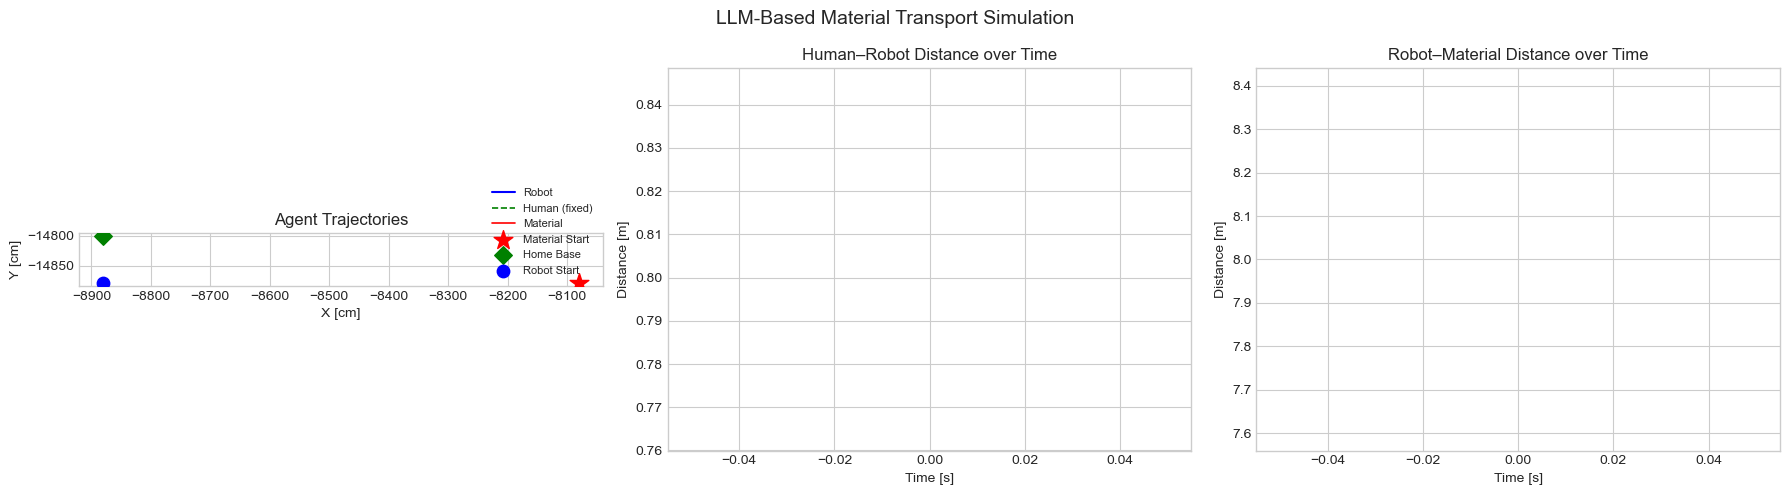

Figure saved: C:\Users\thewi\Dropbox\03_ARCHES\01_main\01_HRC\03_simulation\SimWorld\dev\llm_material_transport\result.png


In [18]:
# ==============================================================
# 結果可視化
# ==============================================================

df = pd.DataFrame(sim_data)

if df.empty:
    print("No data recorded.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("LLM-Based Material Transport Simulation", fontsize=14)

    # --- (1) 軌跡プロット ---
    ax = axes[0]
    ax.plot(df["robot_x"], df["robot_y"], "b-", lw=1.5, label="Robot")
    ax.plot(df["human_x"], df["human_y"], "g--", lw=1.2, label="Human (fixed)")
    ax.plot(df["mat_x"],   df["mat_y"],   "r-",  lw=1.2, label="Material")
    ax.scatter(*MATERIAL_SPAWN[:2], c="red",   marker="*", s=200, zorder=5, label="Material Start")
    ax.scatter(*HOME_XY,             c="green", marker="D", s=80,  zorder=5, label="Home Base")
    ax.scatter(df["robot_x"].iloc[0], df["robot_y"].iloc[0],
               c="blue", marker="o", s=80, zorder=5, label="Robot Start")
    ax.set_xlabel("X [cm]")
    ax.set_ylabel("Y [cm]")
    ax.set_title("Agent Trajectories")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")

    # --- (2) 時系列: Human-Robot 距離 ---
    ax = axes[1]
    ax.plot(df["t"], df["dist_human_robot_cm"] / 100.0, "purple", lw=1.5)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Distance [m]")
    ax.set_title("Human–Robot Distance over Time")

    # --- (3) 時系列: Robot-Material 距離 ---
    ax = axes[2]
    ax.plot(df["t"], df["dist_robot_mat_cm"] / 100.0, "orange", lw=1.5)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Distance [m]")
    ax.set_title("Robot–Material Distance over Time")

    plt.tight_layout()
    output_path = _output_dir / "result.png"
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f"Figure saved: {output_path}")

  [Robot] Picking up mug...
  [Robot] mug picked up.


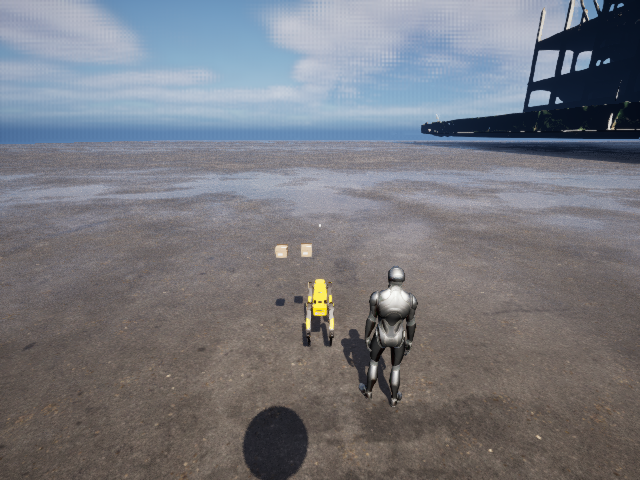

tracking_actor: MT_MaterialMugCarryProxy
mug_exists: True
mug_pos: (-8080.0, -14880.0, -5000.0)
proxy_exists: True
robot: (-8745.008, -14880.0, -188.35)
tracked_material: (-8750.008, -14900.0, -96.35)


In [65]:
probe_stop = threading.Event()
robot_simulate_pickup(probe_stop)

carry_stop = threading.Event()
carry_thread = threading.Thread(target=robot_carry_material, args=(carry_stop,), daemon=True)
carry_thread.start()

for _ in range(3):
    ucv.dog_move(ROBOT_NAME, [ROBOT_SPEED, ROBOT_MOVE_SLICE, 0])
    time.sleep(0.1)

carry_stop.set()
carry_thread.join(timeout=2)

robot_x, robot_y, robot_z = get_pos3d(ROBOT_NAME)
ucv.set_camera_location(0, (robot_x - 450.0, robot_y, robot_z + 260.0))
ucv.set_camera_rotation(0, (-18.0, 0.0, 0.0))
img = ucv.get_image(0, 'lit')
ucv.show_img(img, title='CarryProxyValidation')

tracked_actor = get_material_tracking_name()
mug_pos = get_pos3d(MATERIAL_NAME) if actor_exists(MATERIAL_NAME) else None
try:
    tracked_material_pos = get_pos3d(tracked_actor)
except Exception as exc:
    tracked_material_pos = f'unavailable: {exc}'

print('tracking_actor:', tracked_actor)
print('mug_exists:', actor_exists(MATERIAL_NAME))
print('mug_pos:', mug_pos)
print('proxy_exists:', actor_exists(MATERIAL_CARRY_PROXY_NAME))
print('robot:', get_pos3d(ROBOT_NAME))
print('tracked_material:', tracked_material_pos)